In [1]:
# Importación los paquetes

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
 # Data import (Species and functional traits for each species)

data = pd.read_csv('spp_traits.csv',sep=';')
data.head(5)

,abbr,species,foliose,fruticose,crustose,escuamulose,dimorfic,green_algae,cianobacteria,both,...,small,simple,septate,pluriseptate,cilia,absent_cilia,uv,micro,herb,obs
0,A_chry,Acaropsora_cf._chrysops,0,0,1,0,0,1,0,0,...,1,1,0,0,0,1,0,0,1,0
1,A_alt,Acarospora_altoandina,0,0,1,0,0,1,0,0,...,1,1,0,0,0,1,0,0,0,0
2,A_bol,Acarospora_boliviana,0,0,1,0,0,1,0,0,...,1,1,0,0,0,1,0,0,0,ác_izocárpico__trazas_de_epanorina_y_ác_conrhi...
3,A_lor,Acarospora_lorentzii,0,0,1,0,0,1,0,0,...,1,1,0,0,0,1,0,0,0,ác_nórtico__ác_nórtico__ác_hiposalazínico_-_No...
4,A_sp_1,Acarospora_sp._1_(amarilla),0,0,1,0,0,1,0,0,...,1,1,0,0,0,1,0,0,0,ac_rizocarpico


In [3]:
data.shape

(106, 27)

In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abbr           106 non-null    object
 1   species        106 non-null    object
 2   foliose        106 non-null    int64 
 3   fruticose      106 non-null    int64 
 4   crustose       106 non-null    int64 
 5   escuamulose    106 non-null    int64 
 6   dimorfic       106 non-null    int64 
 7   green_algae    106 non-null    int64 
 8   cianobacteria  106 non-null    int64 
 9   both           106 non-null    int64 
 10  apothecia      106 non-null    int64 
 11  lirella        106 non-null    int64 
 12  perithecia     106 non-null    int64 
 13  soredia        106 non-null    int64 
 14  isidia         106 non-null    int64 
 15  big            106 non-null    int64 
 16  mid            106 non-null    int64 
 17  small          106 non-null    int64 
 18  simple         106 non-null   

In [ ]:
#pd.set_option("display.max_columns", 106) # this is if I want to see all columns

In [5]:
# see last 10 rows
data.tail(10)

,abbr,species,foliose,fruticose,crustose,escuamulose,dimorfic,green_algae,cianobacteria,both,...,small,simple,septate,pluriseptate,cilia,absent_cilia,uv,micro,herb,obs
96,X_hypo,Xanthoparmelia_hypopsila,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,X_micro,Xanthoparmelia_microspora,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,X_mou,Xanthoparmelia_mougeotii,1,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,ácido_úsnico_(mayor);_médula_con_ácido_stictic...
99,X_pli,Xanthoparmelia_plittii,1,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,ácido_úsnico_(mayor);_médula_con_ácido_stictic...
100,X_punc,Xanthoparmelia_punctulata,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101,X_sp,Xanthoparmelia_sp._1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
102,X_sub,Xanthoparmelia_submougeotii,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
103,X_subt,Xanthoparmelia_subtinctina,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
104,X_tar,Xanthoparmelia_taractica,1,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,ácido_consalazínico__ácido_salazínico_y_ácido_...
105,X_wri,Xanthoparmelia_wrightiana,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# show a column
data["abbr"]

0      A_chry
1       A_alt
2       A_bol
3       A_lor
4      A_sp_1
        ...  
101      X_sp
102     X_sub
103    X_subt
104     X_tar
105     X_wri
Name: abbr, Length: 106, dtype: object

In [ ]:
data.abbr # different notation for [], confusing if we name an column as a method

## Create a "Trait List" for each species
This creates a new column in your dataframe that lists all the traits present for that specific species.

In [7]:
# Identify the trait columns (all int64 columns)
# Or manually select them: trait_cols = data.columns[2:26]

trait_cols = data.select_dtypes(include=['int64']).columns
trait_cols

Index(['foliose', 'fruticose', 'crustose', 'escuamulose', 'dimorfic',
       'green_algae', 'cianobacteria', 'both', 'apothecia', 'lirella',
       'perithecia', 'soredia', 'isidia', 'big', 'mid', 'small', 'simple',
       'septate', 'pluriseptate', 'cilia', 'absent_cilia', 'uv', 'micro',
       'herb'],
      dtype='object')

In [8]:
# Create a function to join the column names where value is 1
data['combination'] = data[trait_cols].apply(
    lambda row: ', '.join(row.index[row == 1]), axis=1
)

In [9]:
# Display the result
print(data[['abbr', 'species', 'combination']].head())

     abbr                      species  \
0  A_chry      Acaropsora_cf._chrysops   
1   A_alt        Acarospora_altoandina   
2   A_bol         Acarospora_boliviana   
3   A_lor         Acarospora_lorentzii   
4  A_sp_1  Acarospora_sp._1_(amarilla)   

                                         combination  
0  crustose, green_algae, apothecia, small, simpl...  
1  crustose, green_algae, apothecia, small, simpl...  
2  crustose, green_algae, apothecia, perithecia, ...  
3  crustose, green_algae, apothecia, small, simpl...  
4  crustose, green_algae, apothecia, small, simpl...  


## Group species by their combinations
### Grouping species that share the exact same functional profile

In [10]:
# Group by the combination column we just created
functional_groups = data.groupby('combination')['abbr'].apply(list).reset_index()

# Rename columns for clarity
functional_groups.columns = ['Trait_Combination', 'Species_List']

# Add a column to see how many species share that combination
functional_groups['count'] = functional_groups['Species_List'].apply(len)

# Sort by the most common combinations
functional_groups = functional_groups.sort_values(by='count', ascending=False)

functional_groups.head(5)

,Trait_Combination,Species_List,count
0,,"[Cat, H_sp, L_neg, L_sp_1, Leci, Schae, M_verr...",21
14,"crustose, green_algae, apothecia, small","[L_sp_2, L_verd, L_pol, L_sp_3, Leca, S_reg]",6
17,"crustose, green_algae, apothecia, small, simpl...","[A_alt, A_lor, A_sp_1, A_sp_2, T_atr]",5
50,"foliose, green_algae, soredia, micro","[H_leu, P_pun, P_stic, P_sub]",4
31,"foliose, green_algae, apothecia, isidia, mid, ...","[P_chin, P_crin, P_colo]",3


## Get a list of all "Unique" combinations found in your data
### See the "Menu" of all combinations that actually exist in your dataset

In [11]:
unique_combos = data[trait_cols].apply(lambda x: tuple(x.index[x==1]), axis=1).unique()

for combo in unique_combos:
    print(combo)

('crustose', 'green_algae', 'apothecia', 'small', 'simple', 'absent_cilia', 'herb')
('crustose', 'green_algae', 'apothecia', 'small', 'simple', 'absent_cilia')
('crustose', 'green_algae', 'apothecia', 'perithecia', 'small', 'simple', 'absent_cilia')
('crustose', 'green_algae', 'apothecia', 'small', 'simple')
('crustose', 'green_algae', 'apothecia', 'mid', 'septate', 'absent_cilia')
('crustose', 'green_algae', 'apothecia', 'mid', 'simple')
('crustose', 'green_algae', 'apothecia', 'mid', 'pluriseptate')
('crustose', 'green_algae', 'apothecia', 'isidia', 'small', 'septate')
('crustose', 'green_algae', 'apothecia', 'small', 'septate', 'uv')
('crustose', 'green_algae', 'isidia', 'big', 'septate')
('crustose', 'green_algae', 'apothecia', 'mid', 'septate', 'uv')
('septate',)
()
('dimorfic', 'green_algae', 'apothecia', 'soredia', 'big')
('dimorfic', 'cianobacteria')
('crustose', 'green_algae', 'apothecia', 'big', 'simple')
('crustose', 'green_algae', 'apothecia', 'mid')
('crustose', 'green_alg

In [12]:
# Species frequency
data_fr = pd.read_csv('fr_spp.csv',sep=';')
data_fr.head(5)

,site,A_chry,A_sp_1,A_sp_2,A_alt,A_bol,A_lor,B_sp_2,B_sp_1,B_sp_3,...,X_far,X_hypo,X_micro,X_mou,X_pli,X_punc,X_sub,X_subt,X_tar,X_wr
0,Ch_17,0,26.666.667,0,0,0,36.666.667,0,18,0,...,56.666.665,0,0,0,56.666.665,0,0.0,0,43.333.335,0
1,Ch_18,0,0,0.33333334,0,0,0,0,9.666.667,0,...,2,0,0,0,9.333.333,0,0.0,0,5,0
2,Ch_19A,0,0,0,5,0,0,0,13.666.667,0,...,0,0,0,0,4,0,0.0,0,0,0
3,Ch_19B,0,23.333.333,0,1,0,0,0,26.333.334,0,...,0,0,0,0,0,0,0.0,0,0,0
4,Ch_7A,0,0,0,0,0,0,0,15.666.667,0,...,0,0,0,0,0,16,0.0,46.666.665,0,0


In [13]:
data_fr.shape

(54, 100)

In [14]:
# 1. Create a copy of the data
data_presence = data_fr.copy()

# 2. Identify the species columns (all columns except 'site')
species_cols = data_presence.columns.drop('site')

# 3. Clean and convert
for col in species_cols:
    # We convert to string, remove all dots, then convert to a number.
    # This turns "26.666.667" into 26666667 and "0" into 0.
    # Then we check if it is > 0.
    data_presence[col] = pd.to_numeric(
        data_presence[col].astype(str).str.replace('.', '', regex=False), 
        errors='coerce'
    ).fillna(0)
    
    # Now that they are numbers, convert to 1 (presence) or 0 (absence)
    data_presence[col] = (data_presence[col] > 0).astype(int)

# 4. Check the results
display(data_presence.head())

,site,A_chry,A_sp_1,A_sp_2,A_alt,A_bol,A_lor,B_sp_2,B_sp_1,B_sp_3,...,X_far,X_hypo,X_micro,X_mou,X_pli,X_punc,X_sub,X_subt,X_tar,X_wr
0,Ch_17,0,1,0,0,0,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
1,Ch_18,0,0,1,0,0,0,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,Ch_19A,0,0,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
3,Ch_19B,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,Ch_7A,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0


In [15]:
data_env = pd.read_csv("functional_env.csv", sep = ";")
data_env.head(5)



,site,foliose,fructicose,crustose,escuamulose,dimorphic,ambas,apothecia,soredia,isidia,herb,cilia,uv,micro,elev,orns,slope,elev_c,pend_c
0,Ch_17,0.480403,0.259799,0.240238,0.017134,0.002427,0.000000,0.250018,0.710714,0.058828,0.017134,0.607839,0.399588,0.909332,922,0.000000,85,1,2
1,Ch_18,0.701180,0.082320,0.192079,0.000000,0.024421,0.003018,0.304857,0.643373,0.103631,0.000000,0.551816,0.271380,0.942102,934,0.707107,85,1,2
2,Ch_19A,0.235690,0.428103,0.313190,0.023017,0.000000,0.000000,0.373534,0.586207,0.071897,0.051724,0.568966,0.462586,0.830517,938,-0.707107,90,1,2
3,Ch_19B,0.390000,0.066700,0.543300,0.000000,0.000000,0.000000,0.853300,0.073400,0.073300,0.000000,0.376700,0.283300,0.720000,938,-0.275637,5,1,1
4,Ch_7A,0.233224,0.063606,0.703170,0.000000,0.000000,0.000000,0.766776,0.063606,0.219124,0.000000,0.063606,0.466448,0.512350,1366,0.848048,0,1,1


In [16]:
# Merge specific columns from data_env into data_presence
# We select 'site' plus the three variables you need
data_combined = data_presence.merge(
    data_env[['site', 'orns', 'elev_c', 'pend_c']], 
    on='site', 
    how='left'
)

# Move the environmental columns to the front (optional, for better visibility)
cols = ['site', 'orns', 'elev_c', 'pend_c'] + [c for c in data_combined.columns if c not in ['site', 'orns', 'elev_c', 'pend_c']]
data_combined = data_combined[cols]

# Display the result
display(data_combined.head())

,site,orns,elev_c,pend_c,A_chry,A_sp_1,A_sp_2,A_alt,A_bol,A_lor,...,X_far,X_hypo,X_micro,X_mou,X_pli,X_punc,X_sub,X_subt,X_tar,X_wr
0,Ch_17,0.000000,1,2,0,1,0,0,0,1,...,1,0,0,0,1,0,0,0,1,0
1,Ch_18,0.707107,1,2,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,Ch_19A,-0.707107,1,2,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,Ch_19B,-0.275637,1,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Ch_7A,0.848048,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


## Creating a table with functional strategy for each site
Step 1: Create functional strategies for each species

Step 2: Match species columns between both datasets

Step 3: Convert site × species into long format

Step 4: Add functional strategy information to each species record

Step 5: Create a site × functional strategy presence/absence matrix

Step 6: Summarize functional strategies by elevation and slope

Step 7: Count how many sites have each strategy at each elevation/slope

Step 8: Create a readable table of strategies per elevation/slope


In [17]:
# Create functional strategies for each species

# Columns that are NOT traits
non_trait_cols = ['abbr', 'species', 'obs']

# Trait columns
trait_cols = [col for col in data.columns if col not in non_trait_cols]

# Create a functional strategy as the combination of traits present in each species
data_traits = data.copy()

data_traits['functional_strategy'] = data_traits[trait_cols].apply(
    lambda row: '_'.join(row.index[row == 1]),
    axis=1
)

# Optional: create shorter strategy IDs
strategy_codes = {
    strategy: f"FS_{i+1}"
    for i, strategy in enumerate(data_traits['functional_strategy'].unique())
}

data_traits['strategy_id'] = data_traits['functional_strategy'].map(strategy_codes)

display(data_traits[['abbr', 'species', 'strategy_id', 'functional_strategy']].head())

,abbr,species,strategy_id,functional_strategy
0,A_chry,Acaropsora_cf._chrysops,FS_1,crustose_green_algae_apothecia_small_simple_ab...
1,A_alt,Acarospora_altoandina,FS_2,crustose_green_algae_apothecia_small_simple_ab...
2,A_bol,Acarospora_boliviana,FS_3,crustose_green_algae_apothecia_perithecia_smal...
3,A_lor,Acarospora_lorentzii,FS_2,crustose_green_algae_apothecia_small_simple_ab...
4,A_sp_1,Acarospora_sp._1_(amarilla),FS_2,crustose_green_algae_apothecia_small_simple_ab...


In [18]:
# Match species columns between both datasets
# Environmental/site columns in data_combined
env_cols = ['site', 'orns', 'elev_c', 'pend_c']

# Species columns in data_combined
species_cols = [col for col in data_combined.columns if col not in env_cols]

# Species that exist in both datasets
common_species = [sp for sp in species_cols if sp in data_traits['abbr'].values]

print("Number of species in data_combined:", len(species_cols))
print("Number of species matched with trait data:", len(common_species))

# Optional: check species that did not match
missing_species = [sp for sp in species_cols if sp not in data_traits['abbr'].values]
print("Species without trait information:")
print(missing_species)

Number of species in data_combined: 99
Number of species matched with trait data: 98
Species without trait information:
['X_wr']


In [19]:
# Convert site × species into long format
# This creates a table where each row is a site-species record.

site_species_long = data_combined[env_cols + common_species].melt(
    id_vars=env_cols,
    var_name='abbr',
    value_name='presence'
)

# Keep only species that are present
site_species_long = site_species_long[site_species_long['presence'] == 1]

display(site_species_long.head())

,site,orns,elev_c,pend_c,abbr,presence
8,Ch_16,0.000000,1,2,A_chry,1
54,Ch_17,0.000000,1,2,A_sp_1,1
57,Ch_19B,-0.275637,1,1,A_sp_1,1
66,Ch_24,0.970296,1,1,A_sp_1,1
70,Ch_15A,0.707107,1,2,A_sp_1,1


In [20]:
# merge env and species with functional strategy

site_species_strategy = site_species_long.merge(
    data_traits[['abbr', 'strategy_id', 'functional_strategy']],
    on='abbr',
    how='left'
)

display(site_species_strategy.head())

,site,orns,elev_c,pend_c,abbr,presence,strategy_id,functional_strategy
0,Ch_16,0.000000,1,2,A_chry,1,FS_1,crustose_green_algae_apothecia_small_simple_ab...
1,Ch_17,0.000000,1,2,A_sp_1,1,FS_2,crustose_green_algae_apothecia_small_simple_ab...
2,Ch_19B,-0.275637,1,1,A_sp_1,1,FS_2,crustose_green_algae_apothecia_small_simple_ab...
3,Ch_24,0.970296,1,1,A_sp_1,1,FS_2,crustose_green_algae_apothecia_small_simple_ab...
4,Ch_15A,0.707107,1,2,A_sp_1,1,FS_2,crustose_green_algae_apothecia_small_simple_ab...


In [21]:
# Add functional strategy information to each species record
site_strategy = (
    site_species_strategy
    .groupby(env_cols + ['strategy_id'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to presence/absence
site_strategy = (site_strategy > 0).astype(int)

# Bring site, orns, elev_c, pend_c back as columns
site_strategy = site_strategy.reset_index()

display(site_strategy.head())

strategy_id,site,orns,elev_c,pend_c,FS_1,FS_10,FS_11,FS_12,FS_13,FS_14,...,FS_51,FS_52,FS_53,FS_54,FS_55,FS_56,FS_6,FS_7,FS_8,FS_9
0,Ch12,0.000000,2,1,0,0,0,0,1,0,...,0,0,0,1,0,0,1,0,1,1
1,Ch_10,-0.707107,2,2,0,1,0,0,1,0,...,1,1,0,1,0,0,0,1,1,0
2,Ch_11,0.000000,2,2,0,1,0,0,1,1,...,1,0,0,1,0,0,1,1,0,0
3,Ch_13A,-0.998630,1,1,0,0,0,0,1,0,...,1,0,0,0,0,0,1,0,1,1
4,Ch_13B,0.707107,1,2,0,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0


In [22]:
# Summarize functional strategies by elevation and slope
strategy_cols = [col for col in site_strategy.columns if col.startswith('FS_')]

strategies_by_environment = (
    site_strategy
    .groupby(['elev_c', 'pend_c'])[strategy_cols]
    .max()
    .reset_index()
)

display(strategies_by_environment.head())

strategy_id,elev_c,pend_c,FS_1,FS_10,FS_11,FS_12,FS_13,FS_14,FS_15,FS_16,...,FS_51,FS_52,FS_53,FS_54,FS_55,FS_56,FS_6,FS_7,FS_8,FS_9
0,1,1,0,1,1,1,1,1,0,1,...,1,0,0,1,1,1,1,1,1,1
1,1,2,1,1,1,0,1,1,0,1,...,1,0,0,0,1,0,1,1,1,1
2,2,1,0,1,0,1,1,0,1,0,...,1,1,0,1,1,0,1,1,1,1
3,2,2,0,1,1,0,1,1,1,0,...,1,1,0,1,0,0,1,1,1,1
4,3,1,0,1,1,1,1,0,0,0,...,0,1,1,1,0,1,1,1,0,1


In [23]:
# Count how many sites have each strategy at each elevation/slope
#If instead of presence/absence you want the number of sites where each strategy occurs:

strategy_counts_by_environment = (
    site_strategy
    .groupby(['elev_c', 'pend_c'])[strategy_cols]
    .sum()
    .reset_index()
)

display(strategy_counts_by_environment.head())

strategy_id,elev_c,pend_c,FS_1,FS_10,FS_11,FS_12,FS_13,FS_14,FS_15,FS_16,...,FS_51,FS_52,FS_53,FS_54,FS_55,FS_56,FS_6,FS_7,FS_8,FS_9
0,1,1,0,4,1,1,13,1,0,1,...,12,0,0,1,1,2,11,4,3,8
1,1,2,1,7,4,0,9,2,0,3,...,11,0,0,0,6,0,11,4,1,3
2,2,1,0,5,0,2,6,0,1,0,...,3,2,0,6,4,0,7,5,1,1
3,2,2,0,7,1,0,7,2,1,0,...,6,4,0,4,0,0,6,4,2,1
4,3,1,0,5,4,1,3,0,0,0,...,0,3,1,5,0,1,7,4,0,1


In [24]:
# Create a readable table of strategies per elevation/slope
env_strategy_long = strategies_by_environment.melt(
    id_vars=['elev_c', 'pend_c'],
    var_name='strategy_id',
    value_name='presence'
)

env_strategy_long = env_strategy_long[env_strategy_long['presence'] == 1]

# Add full trait combination description
env_strategy_long = env_strategy_long.merge(
    data_traits[['strategy_id', 'functional_strategy']].drop_duplicates(),
    on='strategy_id',
    how='left'
)

display(env_strategy_long.head())

,elev_c,pend_c,strategy_id,presence,functional_strategy
0,1,2,FS_1,1,crustose_green_algae_apothecia_small_simple_ab...
1,1,1,FS_10,1,crustose_green_algae_isidia_big_septate
2,1,2,FS_10,1,crustose_green_algae_isidia_big_septate
3,2,1,FS_10,1,crustose_green_algae_isidia_big_septate
4,2,2,FS_10,1,crustose_green_algae_isidia_big_septate


In [25]:
# Count how many sites have each strategy at each elevation/slope
site_strategy['functional_strategy_richness'] = site_strategy[strategy_cols].sum(axis=1)

#display(site_strategy[['site', 'orns', 'elev_c', 'pend_c', 'functional_strategy_richness']].head())

df_functional_strategy = site_strategy[['site', 'orns', 'elev_c', 'pend_c', 'functional_strategy_richness']]

df_functional_strategy.head(5)

strategy_id,site,orns,elev_c,pend_c,functional_strategy_richness
0,Ch12,0.000000,2,1,8
1,Ch_10,-0.707107,2,2,18
2,Ch_11,0.000000,2,2,15
3,Ch_13A,-0.998630,1,1,9
4,Ch_13B,0.707107,1,2,8


In [96]:
# Number of functional strategies by elevation/slope
strategy_richness_by_environment = (
    site_strategy
    .groupby(['elev_c', 'pend_c'])['functional_strategy_richness']
    .mean()
    .reset_index()
)

display(strategy_richness_by_environment)

,elev_c,pend_c,functional_strategy_richness
0,1,1,10.307692
1,1,2,14.000000
2,2,1,11.375000
3,2,2,16.625000
4,3,1,10.625000
5,3,2,15.200000


## Plots

C:\Users\usuario\AppData\Local\Temp\ipykernel_8708\613893390.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_functional_strategy, x='elev_c', y='functional_strategy_richness', ax=axes[0], palette="viridis")
C:\Users\usuario\AppData\Local\Temp\ipykernel_8708\613893390.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_functional_strategy, x='pend_c', y='functional_strategy_richness', ax=axes[1], palette="magma")


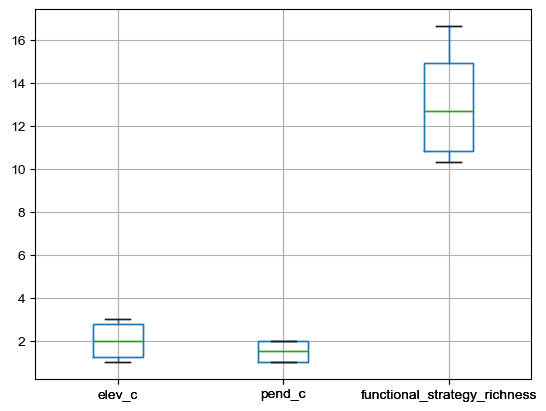

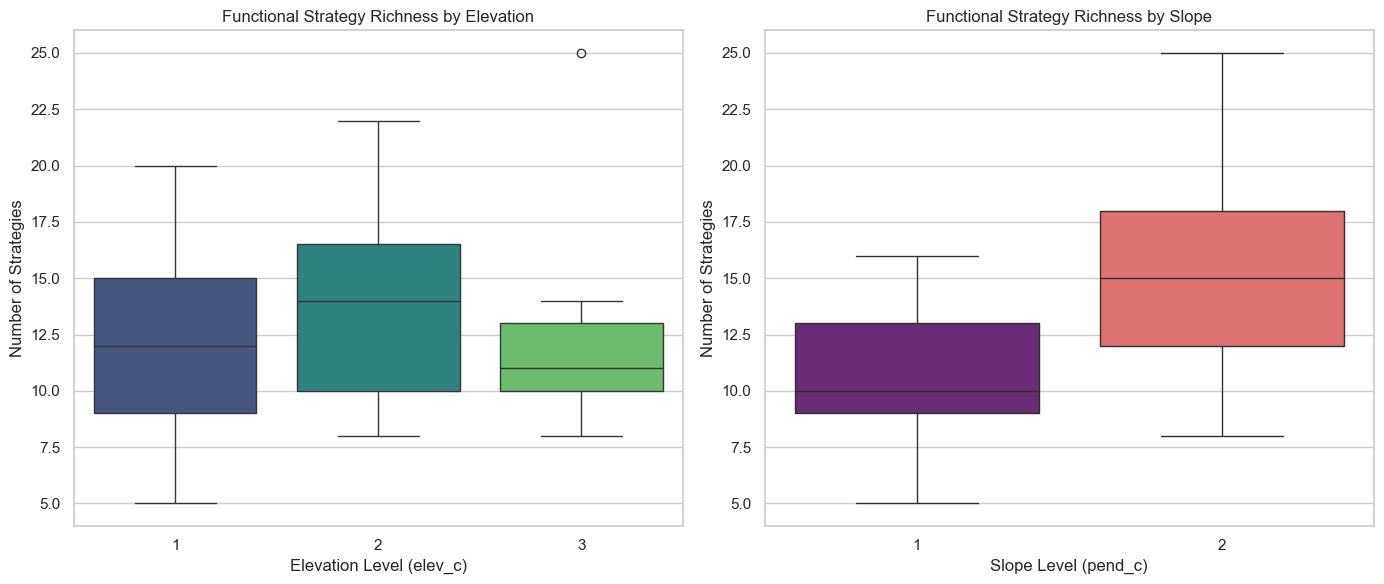

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Elevation vs Richness
sns.boxplot(data=df_functional_strategy, x='elev_c', y='functional_strategy_richness', ax=axes[0], palette="viridis")
axes[0].set_title('Functional Strategy Richness by Elevation')
axes[0].set_xlabel('Elevation Level (elev_c)')
axes[0].set_ylabel('Number of Strategies')

# Plot 2: Slope vs Richness
sns.boxplot(data=df_functional_strategy, x='pend_c', y='functional_strategy_richness', ax=axes[1], palette="magma")
axes[1].set_title('Functional Strategy Richness by Slope')
axes[1].set_xlabel('Slope Level (pend_c)')
axes[1].set_ylabel('Number of Strategies')

plt.tight_layout()
plt.show()

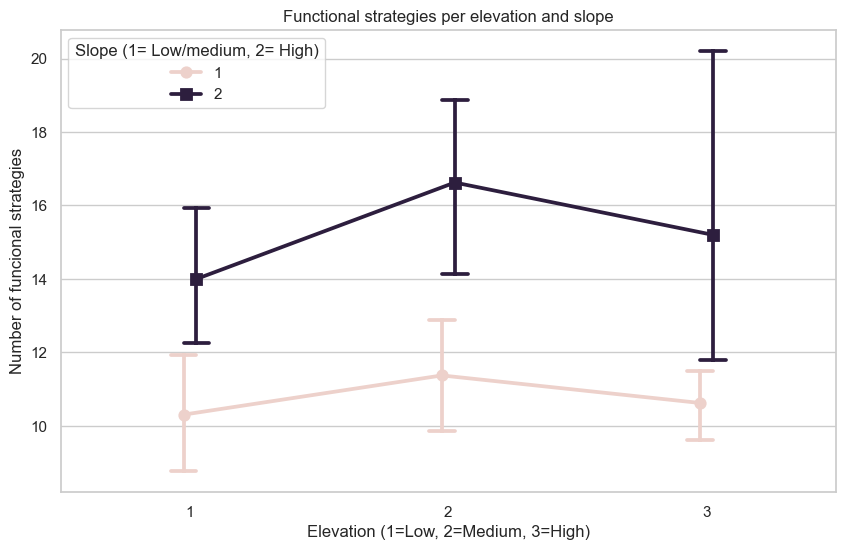

In [120]:
# Interaction Plot (Elevation AND Slope together)

plt.figure(figsize=(10, 6))

# Pointplot shows the mean and the confidence interval
sns.pointplot(
    data=df_functional_strategy, 
    x='elev_c', 
    y='functional_strategy_richness', 
    hue='pend_c', 
    dodge=True, 
    markers=['o', 's', 'D'], 
    capsize=.1
)

plt.title('Functional strategies per elevation and slope')
plt.xlabel('Elevation (1=Low, 2=Medium, 3=High)')
plt.ylabel('Number of funcional strategies')
plt.legend(title='Slope (1= Low/medium, 2= High)')

plt.savefig("func_strategies.png")

plt.show()